In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [17]:
file_path = "/Users/kennyg/Documents/KNN.csv"
data = pd.read_csv(file_path)
data.head()

,crop,moisture,temp,pump
0,cotton,638,16,1
1,cotton,522,18,1
2,cotton,741,22,1
3,cotton,798,32,1
4,cotton,690,28,1


In [19]:
# Checking for null
print("Shape = ", data.shape)
data.isnull().sum()

Shape =  (200, 4)


crop        0
moisture    0
temp        0
pump        0
dtype: int64

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   crop      200 non-null    object
 1   moisture  200 non-null    int64 
 2   temp      200 non-null    int64 
 3   pump      200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [23]:
data["pump"].value_counts()

pump
1    150
0     50
Name: count, dtype: int64

In [25]:
target_ratio = data["pump"].value_counts()/len(data)
print(target_ratio)

pump
1    0.75
0    0.25
Name: count, dtype: float64


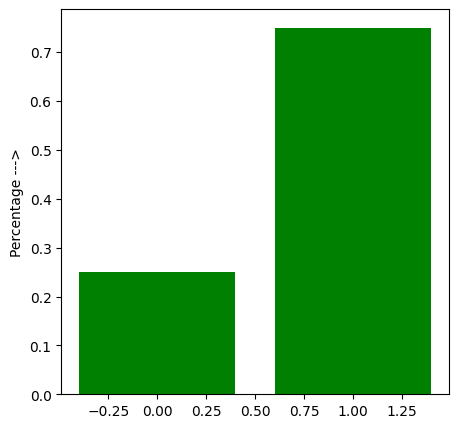

In [27]:
# checking the buiseness of the data
plt.figure(figsize = (5, 5))
plt.bar(target_ratio.index, target_ratio, color = "green")
plt.ylabel("Percentage --->")
plt.show()

In [29]:
# Separating dependent and independent features
x = data.drop(["crop", "pump"], axis=1)
y = data["pump"]

In [33]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 56)
print(x_train.shape, x_test.shape)

(150, 2) (50, 2)


In [37]:
# Gaussian Model Training
gau_model = GaussianNB()
gau_model.fit(x_train, y_train)

GaussianNB()

In [39]:
# Predicting values from unknown and known data
p_test_1 = gau_model.predict(x_test)
p_train_1 = gau_model.predict(x_train)

In [41]:
# Checking the accuracy
print("Train Accuracy: ", metrics.accuracy_score(p_train_1, y_train) * 100, "%")
print("Test Accuracy: ", metrics.accuracy_score(p_test_1, y_test) * 100, "%")
g = metrics.accuracy_score(p_test_1, y_test) * 100

Train Accuracy:  98.66666666666667 %
Test Accuracy:  98.0 %
